What is the Problem?

We want to detect if a coin is fair (i.e., probability of heads = 0.5) or biased (e.g., probability of heads > 0.5 or < 0.5) using Bayesian inference.


Objective
We want to estimate the probability that a coin lands heads (H) using Bayesian inference and see if the coin is fair or biased.

🧠 Step 1: Bayesian Concept
Bayes’ theorem:

𝑃
(
𝜃
∣
𝐷
)
=
𝑃
(
𝐷
∣
𝜃
)
⋅
𝑃
(
𝜃
)
𝑃
(
𝐷
)
P(θ∣D)=
P(D)
P(D∣θ)⋅P(θ)
​

𝜃
θ = probability of heads.

𝐷
D = data (number of heads and tails).

𝑃
(
𝜃
)
P(θ) = prior belief about
𝜃
θ.

𝑃
(
𝐷
∣
𝜃
)
P(D∣θ) = likelihood of seeing this data.

𝑃
(
𝜃
∣
𝐷
)
P(θ∣D) = updated belief (posterior) after seeing the data.

Step 2: Simulate Coin Toss Data



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a biased coin toss: P(heads) = 0.7
true_p = 0.7
n_trials = 1000
tosses = np.random.binomial(1, true_p, n_trials)

# Count heads and tails
heads = np.sum(tosses)
tails = n_trials - heads

print(f"Heads: {heads}, Tails: {tails}")


Heads: 716, Tails: 284


🎯 Step 3: Define Prior Distribution
We assume a Beta distribution prior for
𝜃
θ, because it’s a conjugate prior for Binomial likelihood.

Beta
(
𝛼
,
𝛽
)
⇒
𝑃
(
𝜃
)
=
𝜃
𝛼
−
1
(
1
−
𝜃
)
𝛽
−
1
𝐵
(
𝛼
,
𝛽
)
Beta(α,β)⇒P(θ)=
B(α,β)
θ
α−1
 (1−θ)
β−1

​



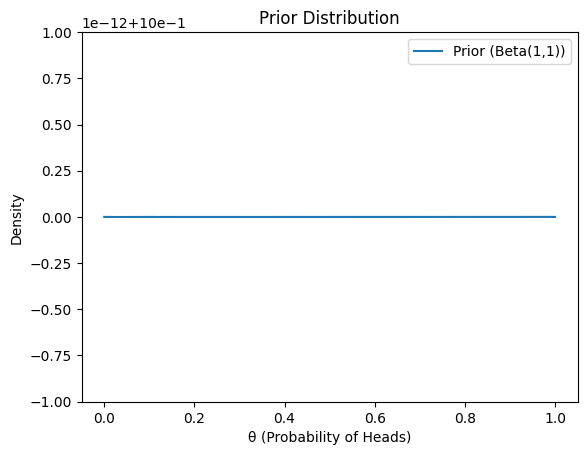

In [2]:
from scipy.stats import beta

# Prior belief: uniform (we think all p values are equally likely)
alpha_prior = 1
beta_prior = 1

theta_range = np.linspace(0, 1, 1000)
prior = beta.pdf(theta_range, alpha_prior, beta_prior)

plt.plot(theta_range, prior, label='Prior (Beta(1,1))')
plt.xlabel('θ (Probability of Heads)')
plt.ylabel('Density')
plt.title('Prior Distribution')
plt.legend()
plt.show()


Step 4: Likelihood Function
The likelihood is the probability of observing our data (heads/tails) given θ.

Since data is Binomial:

𝑃
(
𝐷
∣
𝜃
)
=
𝜃
heads
⋅
(
1
−
𝜃
)
tails
P(D∣θ)=θ
heads
 ⋅(1−θ)
tails



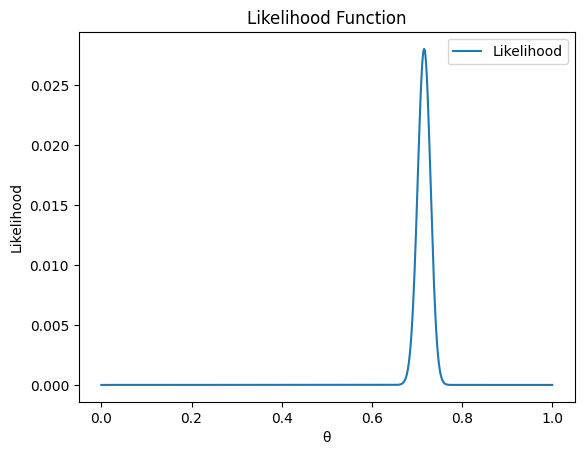

In [3]:
# Likelihood (unnormalized)
likelihood = theta_range**heads * (1 - theta_range)**tails
likelihood /= np.sum(likelihood)  # normalize to plot

plt.plot(theta_range, likelihood, label='Likelihood')
plt.xlabel('θ')
plt.ylabel('Likelihood')
plt.title('Likelihood Function')
plt.legend()
plt.show()


Step 5: Posterior Calculation
Posterior
=
Beta
(
𝛼
+
heads
,
𝛽
+
tails
)
Posterior=Beta(α+heads,β+tails)

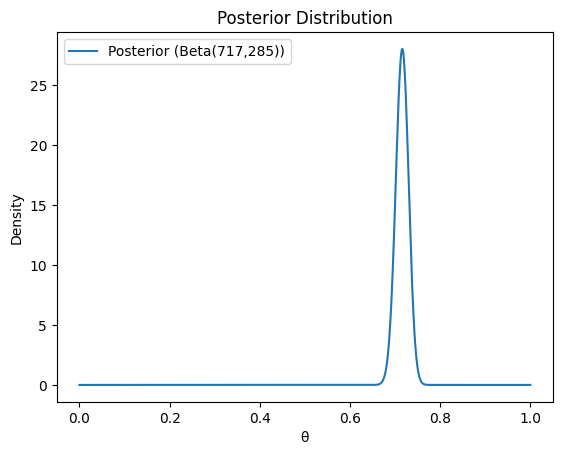

In [4]:
alpha_post = alpha_prior + heads
beta_post = beta_prior + tails

posterior = beta.pdf(theta_range, alpha_post, beta_post)

plt.plot(theta_range, posterior, label=f'Posterior (Beta({alpha_post},{beta_post}))')
plt.xlabel('θ')
plt.ylabel('Density')
plt.title('Posterior Distribution')
plt.legend()
plt.show()


 Step 6: Analyze Posterior
Let’s compute some statistics like:

Mean estimate of θ

MAP (maximum a posteriori)

Credible interval (95%)

In [5]:
mean_estimate = alpha_post / (alpha_post + beta_post)
map_estimate = theta_range[np.argmax(posterior)]
cred_interval = beta.interval(0.95, alpha_post, beta_post)

print(f"Mean Estimate of θ: {mean_estimate:.4f}")
print(f"MAP Estimate of θ: {map_estimate:.4f}")
print(f"95% Credible Interval: {cred_interval}")


Mean Estimate of θ: 0.7156
MAP Estimate of θ: 0.7157
95% Credible Interval: (np.float64(0.6872496554263341), np.float64(0.7430729990864491))


All joined one code

In [19]:

# Step 1: Prior belief (before seeing data)
# Let's assume a uniform prior (Beta(1, 1)) → no prior bias
a_prior = 1
b_prior = 1

# Step 2: Observed data
n_trials = 100
n_heads = 70
n_tails = n_trials - n_heads

# Step 3: Posterior update (using Beta posterior)
# Posterior parameters: a_post = a_prior + heads, b_post = b_prior + tails
a_post = a_prior + n_heads
b_post = b_prior + n_tails
print("Alpha posterior and beta posterior is :",a_post,b_post)


Alpha posterior and beta posterior is : 71 31


In [20]:
# Step 4: Visualization of prior and posterior
theta = np.linspace(0, 1, 1000)


In [21]:
theta

array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
       0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
       0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
       0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
       0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
       0.07007007, 0.07107107, 0.07207207, 0.07307307, 0.07407

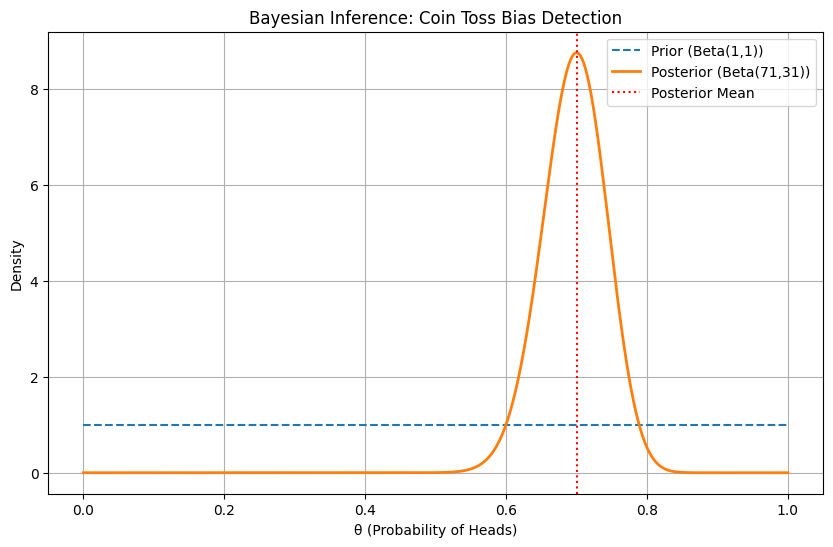

In [22]:

plt.figure(figsize=(10, 6))
plt.plot(theta, beta.pdf(theta, a_prior, b_prior), label='Prior (Beta(1,1))', linestyle='--')
plt.plot(theta, beta.pdf(theta, a_post, b_post), label=f'Posterior (Beta({a_post},{b_post}))', linewidth=2)
plt.axvline(x=(a_post - 1)/(a_post + b_post - 2), color='red', linestyle=':', label='Posterior Mean')
plt.title("Bayesian Inference: Coin Toss Bias Detection")
plt.xlabel("θ (Probability of Heads)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# Step 5: Compute posterior distribution
posterior_pdf = beta.pdf(theta_range, a_post, b_post)

# Step 6: Mean estimate of θ
mean_estimate = a_post / (a_post + b_post)

# Step 7: MAP estimate (maximum a posteriori)
map_estimate = theta_range[np.argmax(posterior_pdf)]

# Step 8: 95% Credible Interval
cred_interval = beta.interval(0.95, a_post, b_post)

In [24]:
print(f"Mean Estimate of θ: {mean_estimate:.4f}")
print(f"MAP Estimate of θ: {map_estimate:.4f}")
print(f"95% Credible Interval: {cred_interval}")


Mean Estimate of θ: 0.6961
MAP Estimate of θ: 0.6997
95% Credible Interval: (np.float64(0.603852871352311), np.float64(0.7810212736959659))


Let’s interpret the results:

---

###  **Results:**

* **Mean Estimate of θ: 0.6961**

  * This is the **posterior mean** of the coin landing heads, based on the observed data.
  * It means **there’s a \~69.61% probability** the coin lands heads, on average, after updating our beliefs with the data.

* **MAP Estimate of θ: 0.6997**

  * This is the **Maximum A Posteriori** estimate — the value of θ that **maximizes** the posterior probability.
  * Here, it's **\~69.97%**, which is close to the mean, indicating a **unimodal posterior**.

* **95% Credible Interval: (0.6039, 0.7810)**

  * This means there's a **95% probability** that the true value of θ lies **between 60.39% and 78.10%**.
  * In Bayesian inference, this interval reflects the **degree of certainty** in the estimation after seeing the data.

---

###  What This Tells You:

* The coin is **likely biased toward heads**, as both the mean and MAP estimates are significantly above 0.5.
* The credible interval **does not include 0.5**, strengthening the belief that the coin **is not fair**.
* You can now say, **with 95% certainty**, that the bias θ is between 0.60 and 0.78 — indicating **a strong head bias**.
